# Embeddings & Retrieval-Augmented Generation (RAG)
### A Graduate-Level, Hands-On Teaching Notebook

**Audience:** Graduate students in CS / Data Science / Cybersecurity AI.

**Format:** Each topic has three parts —
1. 📊 a *slide* (bullet points) you can project,
2. 🎤 an *instructor script* to read and explain, and
3. 💻 a *runnable code example* with clean output.

**Design choice:** All examples run **locally and offline** using open-source models (`sentence-transformers`, `scikit-learn`, `faiss`). No API keys are required, so the notebook is fully reproducible in class.

---

## Learning Objectives
By the end of this notebook, students will be able to:
- Explain what an embedding is and how it differs from hashing and classical vectorization.
- Distinguish static vs. contextual embeddings and the role of attention.
- Measure semantic similarity and reason about vector geometry.
- Chunk documents, build a vector index, retrieve, and **re-rank** results.
- Assemble a complete RAG pipeline and recognize common failure modes.

## 🛠️ Setup — Install & Import

Run this once. The first model download is ~90 MB and is cached afterward.

In [ ]:
# If running locally / Colab, uncomment to install:
#!pip install -q sentence-transformers scikit-learn faiss-cpu matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print('Core libraries loaded.')

Core libraries loaded.


In [3]:
# Load a small, fast, high-quality sentence-embedding model (384 dims).
# This is the workhorse for the rest of the notebook.
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded:', model.get_sentence_embedding_dimension(), 'dimensions')

c:\Users\huber\Documents\CyberAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\huber\Documents\CyberAI\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\huber\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In

Model loaded: 384 dimensions


C:\Users\huber\AppData\Local\Temp\ipykernel_380\1437023167.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Model loaded:', model.get_sentence_embedding_dimension(), 'dimensions')


# 🧠 1 — What is an Embedding?

- Text → vector (a list of numbers)
- **Fixed-length** representation
- Captures **semantic meaning**, not spelling
- Similar meaning → nearby vectors
- The foundation of modern AI retrieval

> ### 🎤 Instructor Script
>
> An embedding converts human language into numbers so a machine can reason about *meaning* mathematically. Instead of treating words as isolated symbols, we map them into a high-dimensional vector space where distance reflects similarity in meaning. The words “cat” and “dog” land near each other, while “cat” and “car” sit far apart. This lets us do similarity search, clustering, classification, and retrieval with simple geometry. Embeddings power semantic search, recommendation engines, and the retrieval step of RAG. The single idea I want students to keep: **embeddings represent meaning, not text**. Everything else in this notebook builds on that one shift in perspective.

In [5]:
vec = model.encode('cat')
print('Type          :', type(vec).__name__)
print('Dimensions    :', vec.shape[0])
print('First 5 values:', vec[:5])
print('Vector norm   :', round(float(np.linalg.norm(vec)), 4))

Type          : ndarray
Dimensions    : 384
First 5 values: [ 0.037  0.051 -0.     0.06  -0.117]
Vector norm   : 1.0


# 🔠 2 — From Text to Numbers: Classical Vectorization

- One-hot: 1 dimension per word, mostly zeros
- Bag-of-Words (BoW): counts of words
- **Sparse** & **high-dimensional**
- No notion of meaning or word order
- The pre-deep-learning baseline

> ### 🎤 Instructor Script
>
> Before neural embeddings, we turned text into numbers with counting. One-hot encoding gives each vocabulary word its own dimension — a vector that is all zeros except a single 1. Bag-of-Words extends this to counts across a document. These representations are *sparse* (mostly zeros), *huge* (one dimension per vocabulary word), and crucially they encode **identity, not meaning**: “great” and “excellent” are as different as “great” and “banana.” There is no similarity structure. Understanding this baseline matters because it shows precisely what dense embeddings buy us: a compact space where geometric closeness equals semantic closeness.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = ['the cat sat', 'the dog sat', 'the car drove']
cv = CountVectorizer()
X = cv.fit_transform(corpus)

print('Vocabulary:', cv.get_feature_names_out())
print('\nBag-of-Words matrix (rows = docs):')
print(X.toarray())
print('\nNote: shape =', X.shape, '-> 1 column per unique word, mostly zeros.')

Vocabulary: ['car' 'cat' 'dog' 'drove' 'sat' 'the']

Bag-of-Words matrix (rows = docs):
[[0 1 0 0 1 1]
 [0 0 1 0 1 1]
 [1 0 0 1 0 1]]

Note: shape = (3, 6) -> 1 column per unique word, mostly zeros.


# 📈 3 — TF-IDF: Smarter Counting

- Term Frequency × Inverse Document Frequency
- Down-weights common words (“the”, “is”)
- Up-weights rare, distinctive words
- Still sparse, still no semantics
- A strong, cheap retrieval baseline (BM25 cousin)

> ### 🎤 Instructor Script
>
> TF-IDF improves on raw counts by asking: how *distinctive* is this word? Term frequency rewards words that appear often in a document; inverse document frequency penalizes words that appear in *every* document. The product highlights terms that characterize a specific document — “backpropagation” matters more than “the.” TF-IDF and its ranking cousin BM25 still power production search and remain a strong baseline you should always compare against. But notice the ceiling: it matches on *words*, not *meaning*. A query for “automobile” will not match a document about “cars.” That gap is exactly what dense embeddings close.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = ['the cat sat on the mat',
        'the dog sat on the log',
        'neural networks learn representations']
tfidf = TfidfVectorizer()
M = tfidf.fit_transform(docs).toarray()

import numpy as np
vocab = tfidf.get_feature_names_out()
for i, row in enumerate(M):
    top = np.argsort(row)[::-1][:3]
    terms = [(vocab[j], round(row[j], 2)) for j in top if row[j] > 0]
    print(f'Doc {i}: top terms ->', terms)

Doc 0: top terms -> [('the', np.float64(0.65)), ('cat', np.float64(0.43)), ('mat', np.float64(0.43))]
Doc 1: top terms -> [('the', np.float64(0.65)), ('log', np.float64(0.43)), ('dog', np.float64(0.43))]
Doc 2: top terms -> [('representations', np.float64(0.5)), ('networks', np.float64(0.5)), ('neural', np.float64(0.5))]


# 🔐 4 — Embeddings vs Hashing

- Both: variable input → fixed-length output
- Hashing = **identity** (security, lookup)
- Embeddings = **meaning** (similarity)
- Tiny input change → totally different hash
- Tiny meaning change → nearby embedding

> ### 🎤 Instructor Script
>
> Students often conflate embeddings with hashing because both map variable-length input to a fixed-length output. The *purpose* is opposite. A cryptographic hash is designed so that changing one character scrambles the entire output — there is deliberately **no** similarity between the hashes of “cat” and “cats.” That is what makes hashing good for integrity checks and dictionary lookups. Embeddings are designed for the reverse: small changes in meaning produce small changes in the vector, so “cat” and “cats” land almost on top of each other. The conceptual shift is from **exact match** to **semantic similarity** — and that shift is what makes modern search possible.

In [8]:
import hashlib

def sha(s):
    return hashlib.sha256(s.encode()).hexdigest()[:12]

print('--- Hashing: no similarity ---')
print('cat :', sha('cat'))
print('cats:', sha('cats'), '<- completely different\n')

from numpy import dot
from numpy.linalg import norm
a, b = model.encode('cat'), model.encode('cats')
cos = dot(a, b) / (norm(a) * norm(b))
print('--- Embedding: high similarity ---')
print('cosine(cat, cats) =', round(float(cos), 3), '<- nearly identical meaning')

--- Hashing: no similarity ---
cat : 77af778b51ab
cats: d936608baaac <- completely different

--- Embedding: high similarity ---
cosine(cat, cats) = 0.87 <- nearly identical meaning


# ⚙️ 5 — Static vs Contextual Embeddings

- Word2Vec/GloVe: one fixed vector per word (**static**)
- Problem: “bank” (money) vs “bank” (river)
- Transformers: vector depends on **context**
- **Attention** mixes in surrounding words
- Today we embed *sentences*, not just words

> ### 🎤 Instructor Script
>
> Early models like Word2Vec gave every word a single fixed vector — “bank” had one representation regardless of context. That breaks on polysemy: a financial “bank” and a river “bank” are unrelated, yet share a vector. Transformer models produce *contextual* embeddings: the representation of a word is computed from the whole sentence through the **attention mechanism**, which lets each token ‘look at’ the others. So “bank” near “money” and “bank” near “river” get different vectors. Sentence-transformer models pool these token vectors into a single sentence embedding. The takeaway: modern embeddings represent **meaning in context**, which is why they handle real, ambiguous language so well.

In [9]:
pairs = [
    ('I deposited money at the bank',   'the bank approved my loan'),
    ('I deposited money at the bank',   'we sat on the river bank'),
]
for s1, s2 in pairs:
    e1, e2 = model.encode([s1, s2])
    cos = float(np.dot(e1, e2) / (np.linalg.norm(e1) * np.linalg.norm(e2)))
    print(f'{cos:.3f}  | {s1!r}  vs  {s2!r}')
print('\nSame word \'bank\', but financial vs river context scores lower similarity.')

0.486  | 'I deposited money at the bank'  vs  'the bank approved my loan'
0.430  | 'I deposited money at the bank'  vs  'we sat on the river bank'

Same word 'bank', but financial vs river context scores lower similarity.


# 📏 6 — Measuring Similarity

- **Cosine similarity**: angle between vectors, range [-1, 1]
- 1 = same direction (meaning), 0 = unrelated
- Dot product: cosine when vectors are normalized
- Euclidean distance: straight-line gap
- Cosine is the default for text retrieval

> ### 🎤 Instructor Script
>
> Embeddings are only useful once we can compare them. The dominant metric for text is **cosine similarity**, the cosine of the angle between two vectors. It focuses on *direction* — which encodes meaning — and ignores magnitude, so longer texts aren’t unfairly favored. A score near 1 means ‘almost the same meaning,’ near 0 means ‘unrelated,’ and negative means ‘opposed.’ When vectors are L2-normalized, cosine and dot product are equivalent, which is why vector databases often store normalized vectors and use a fast dot product. Euclidean distance is an alternative but is sensitive to magnitude. Similarity metrics are what turn a pile of numbers into actionable ranking.

In [10]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

words = ['cat', 'kitten', 'dog', 'car']
embs = model.encode(words)

print('Cosine similarity to "cat":')
for w, e in zip(words, embs):
    bar = '#' * int(cosine(embs[0], e) * 20)
    print(f'  cat <-> {w:7s}: {cosine(embs[0], e):.3f}  {bar}')

Cosine similarity to "cat":
  cat <-> cat    : 1.000  ####################
  cat <-> kitten : 0.788  ###############
  cat <-> dog    : 0.661  #############
  cat <-> car    : 0.463  #########


# 🧩 7 — Why Fixed Dimensions?

- Every vector has the **same length** (e.g. 384, 768, 1536)
- Enables uniform storage & fast comparison
- Independent of input length
- More dims = richer meaning, higher cost
- A model design tradeoff

> ### 🎤 Instructor Script
>
> Every embedding from a given model has the same number of dimensions — 384 for MiniLM, 768 for many BERT models, 1536 for some commercial APIs — regardless of whether the input is one word or a paragraph. This uniformity is what makes vectors comparable and storable in a single matrix or index; you cannot take the cosine of two vectors of different lengths. Dimensionality is a capacity knob: more dimensions can encode finer distinctions but cost more memory and compute and can need more data to use well. The practical lesson: pick a dimensionality that balances accuracy against storage and latency for your system.

In [11]:
samples = ['hi', 'machine learning', 'a much longer sentence about neural retrieval systems']
for s in samples:
    e = model.encode(s)
    print(f'len(input_words)={len(s.split()):2d}  ->  embedding dims = {e.shape[0]}')
print('\nInput length varies; output dimensionality is constant.')

len(input_words)= 1  ->  embedding dims = 384
len(input_words)= 2  ->  embedding dims = 384
len(input_words)= 8  ->  embedding dims = 384

Input length varies; output dimensionality is constant.


# 🌍 8 — Choosing an Embedding Model

- Open-source: MiniLM (384), BGE, E5 — free, local
- Commercial APIs: often 768–3072 dims
- Each model has its **own vector space**
- Vectors from different models are **not** comparable
- Choose on accuracy, cost, latency, privacy

> ### 🎤 Instructor Script
>
> There is no single ‘best’ embedding model; there is a best fit for your constraints. Open-source models such as MiniLM, BGE, and E5 run locally for free and keep data private — ideal for teaching and for sensitive domains like security. Commercial APIs may offer higher accuracy at the cost of money, latency, and sending data off-site. The critical gotcha: **each model defines its own vector space.** An embedding from model A is meaningless to model B, so you must embed your queries and your documents with the *same* model, and you must re-embed everything if you switch models. Evaluate candidates on a benchmark like MTEB plus your own data before committing.

In [12]:
# Conceptual comparison (no downloads needed)
models_info = [
    ('all-MiniLM-L6-v2', 384,  'fast, local, great default'),
    ('all-mpnet-base-v2', 768, 'higher quality, slower'),
    ('bge-large-en-v1.5', 1024,'top open-source retrieval'),
    ('text-embedding-3-small', 1536, 'commercial API'),
]
print(f"{'model':24s}{'dims':>6s}  notes")
print('-' * 60)
for name, dims, note in models_info:
    print(f'{name:24s}{dims:6d}  {note}')

model                     dims  notes
------------------------------------------------------------
all-MiniLM-L6-v2           384  fast, local, great default
all-mpnet-base-v2          768  higher quality, slower
bge-large-en-v1.5         1024  top open-source retrieval
text-embedding-3-small    1536  commercial API


# 🧭 9 — Vector Space Intuition

- Embeddings live in high-dimensional space
- Distance ≈ difference in meaning
- Related concepts form **clusters**
- We use PCA/t-SNE to visualize in 2-D
- Geometry is the mental model to keep

> ### 🎤 Instructor Script
>
> It helps to *see* the space. Real embeddings have hundreds of dimensions, which we cannot draw, so we project them down to two dimensions with PCA. When we do, structure appears: animals cluster together, vehicles cluster elsewhere, and unrelated concepts sit far apart. Each axis after projection no longer has a clean human label, but the *relative* positions are meaningful — neighbors share meaning. This geometric picture is the mental model I want students to carry: retrieval is just ‘find my nearest neighbors in this space,’ clustering is ‘find dense groups,’ and classification is ‘which region am I in.’ The plot below makes that concrete.

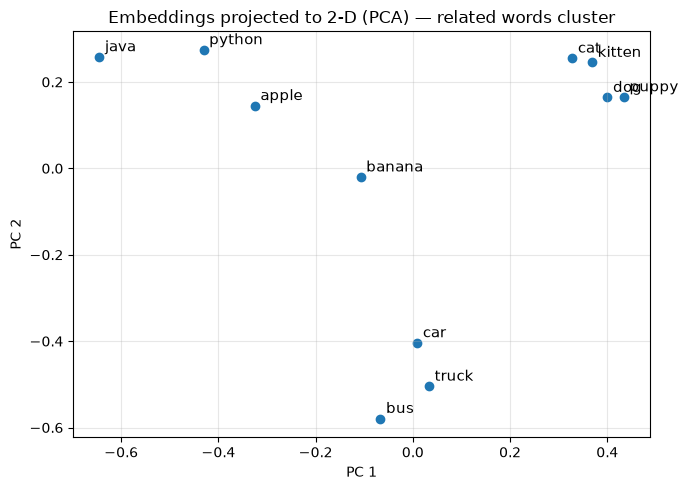

In [13]:
from sklearn.decomposition import PCA

terms = ['cat','dog','kitten','puppy','car','truck','bus','python','java','banana','apple']
E = model.encode(terms)
pts = PCA(n_components=2).fit_transform(E)

plt.figure(figsize=(7,5))
plt.scatter(pts[:,0], pts[:,1])
for (x,y), t in zip(pts, terms):
    plt.annotate(t, (x,y), fontsize=11, xytext=(4,4), textcoords='offset points')
plt.title('Embeddings projected to 2-D (PCA) — related words cluster')
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 📚 10 — Chunking Documents

- Don’t embed a whole document as one vector
- One vector = an **average** of all topics (blurry)
- Split into chunks (~100–500 tokens)
- Each chunk → its own embedding
- Enables precise, passage-level retrieval

> ### 🎤 Instructor Script
>
> If you embed an entire document into a single vector, you get the *average* of everything it discusses — a blurry centroid that matches nothing sharply. The fix is **chunking**: split the document into smaller passages, typically a few hundred tokens, and embed each one separately. Now a query about a narrow topic can match the specific passage that covers it, instead of competing with the whole document’s mixed signal. Chunking is one of the highest-leverage practical decisions in RAG: too large and retrieval is imprecise; too small and you lose context. The right size depends on your content and model, and it is worth tuning empirically.

In [14]:
def chunk_words(text, size=8):
    words = text.split()
    return [' '.join(words[i:i+size]) for i in range(0, len(words), size)]

doc = ('Neural networks are trained with backpropagation. '
       'Gradients flow backward to update weights. '
       'Embeddings map text into vector space for retrieval.')
chunks = chunk_words(doc, size=6)
for i, c in enumerate(chunks):
    print(f'chunk {i}: {c!r}')
print(f'\n{len(chunks)} chunks -> {len(chunks)} embeddings of dim {model.encode(chunks).shape[1]}')

chunk 0: 'Neural networks are trained with backpropagation.'
chunk 1: 'Gradients flow backward to update weights.'
chunk 2: 'Embeddings map text into vector space'
chunk 3: 'for retrieval.'

4 chunks -> 4 embeddings of dim 384


# 🔁 11 — Overlapping Chunks

- Add overlap between consecutive chunks
- Prevents losing ideas split at boundaries
- Typical overlap: 10–20% of chunk size
- Improves recall & continuity
- Costs a little extra storage

> ### 🎤 Instructor Script
>
> A naive split can cut a sentence or idea exactly at a chunk boundary, leaving neither chunk with the full thought. The remedy is **overlapping windows**: let each chunk repeat the last few tokens of the previous one. With overlap, a concept that straddles the boundary appears intact in at least one chunk, so retrieval still finds it. A common setting is 10–20% overlap. The cost is modest — slightly more chunks and storage — but the recall and continuity gains are usually worth it. This is a small, easy-to-miss detail that meaningfully improves real systems, so I always have students implement it explicitly.

In [15]:
def chunk_overlap(text, size=6, overlap=2):
    words = text.split(); out = []; step = size - overlap
    for i in range(0, len(words), step):
        piece = words[i:i+size]
        if piece: out.append(' '.join(piece))
        if i + size >= len(words): break
    return out

doc = 'training uses backpropagation to update the network weights efficiently every step'
for i, c in enumerate(chunk_overlap(doc, size=6, overlap=2)):
    print(f'chunk {i}: {c!r}')
print('\nNote how the last words of each chunk reappear at the start of the next.')

chunk 0: 'training uses backpropagation to update the'
chunk 1: 'update the network weights efficiently every'
chunk 2: 'efficiently every step'

Note how the last words of each chunk reappear at the start of the next.


# 🗃️ 12 — Building a Searchable Index

- Embed every chunk → a matrix [N × dim]
- Normalize vectors for fast cosine via dot product
- Store alongside the original text
- This matrix *is* your knowledge base
- Next: search it

> ### 🎤 Instructor Script
>
> To search, we first turn our corpus into an index. Concretely, we embed every chunk and stack the vectors into an N-by-dimension matrix, keeping a parallel list of the original texts so we can return human-readable results. If we L2-normalize each row, a single matrix multiplication against a normalized query vector yields all cosine similarities at once — fast and simple. For a few thousand chunks this brute-force approach is perfectly adequate and easy to reason about. The matrix we build here is the knowledge base the rest of the pipeline queries; everything downstream is just ‘compare the query to these rows and rank.’

In [16]:
corpus = [
    'The capital of France is Paris.',
    'Photosynthesis converts sunlight into chemical energy in plants.',
    'Backpropagation trains neural networks by computing gradients.',
    'The Great Wall of China is visible as a long stone fortification.',
    'Cosine similarity measures the angle between two vectors.',
    'Transformers use attention to model relationships between tokens.',
]
emb = model.encode(corpus, normalize_embeddings=True)
print('Index matrix shape:', emb.shape, '(rows = chunks, cols = dims)')
print('Row norms (≈1.0 after normalization):', np.round(np.linalg.norm(emb, axis=1), 3))

Index matrix shape: (6, 384) (rows = chunks, cols = dims)
Row norms (≈1.0 after normalization): [1. 1. 1. 1. 1. 1.]


# 🔍 13 — Retrieval (Top-k Search)

- Embed the query with the **same** model
- Compute similarity vs every chunk
- Return the top-k highest scores
- Fast, scalable, **approximate**
- Step 1 of the two-stage pipeline

> ### 🎤 Instructor Script
>
> Retrieval is the first search stage. We embed the user’s query with the *same* model used for the corpus, compute its similarity to every stored chunk, and return the top-k matches. With normalized vectors this is one dot product against the index matrix — milliseconds for thousands of chunks, and scalable to billions with approximate nearest neighbor indexes. The crucial property is that retrieval is *fast but approximate*: it casts a wide, cheap net to find plausibly relevant passages. It does not deeply judge each candidate — that is the job of the next stage, re-ranking. Watch how the relevant chunk rises to the top below.

In [17]:
def retrieve(query, k=3):
    q = model.encode(query, normalize_embeddings=True)
    scores = emb @ q                      # cosine via dot product
    idx = np.argsort(scores)[::-1][:k]
    return [(float(scores[i]), corpus[i]) for i in idx]

query = 'How are neural networks trained?'
print('Query:', query, '\n')
for rank, (s, text) in enumerate(retrieve(query), 1):
    print(f'{rank}. ({s:.3f}) {text}')

Query: How are neural networks trained? 

1. (0.665) Backpropagation trains neural networks by computing gradients.
2. (0.174) Transformers use attention to model relationships between tokens.
3. (0.102) The capital of France is Paris.


# 🗄️ 14 — Vector Databases & ANN

- Brute force is O(N) per query — fine for thousands
- Billions of vectors need **Approximate NN**
- Indexes: IVF (clustering), HNSW (graph)
- Trade a little accuracy for huge speed
- Tools: FAISS, Milvus, Pinecone, pgvector

> ### 🎤 Instructor Script
>
> Computing similarity against every vector is linear in corpus size — fine for thousands, hopeless for billions. Vector databases solve this with **Approximate Nearest Neighbor** indexes. IVF partitions vectors into clusters and searches only the nearest few; HNSW builds a navigable small-world graph you can traverse in roughly logarithmic time. Both trade a sliver of recall for orders-of-magnitude speedups, and both expose knobs to tune that tradeoff. Production tools — FAISS, Milvus, Pinecone, Weaviate, pgvector — wrap these algorithms with persistence, metadata filtering, and scaling. The mental model stays the same as our numpy index; the database just makes nearest-neighbor search fast at scale.

In [18]:
# FAISS exact index — same results as numpy, but production-grade.
# (Falls back to numpy if faiss isn't installed.)
try:
    import faiss
    index = faiss.IndexFlatIP(emb.shape[1])   # inner product = cosine (normalized)
    index.add(emb.astype('float32'))
    q = model.encode('attention mechanism in transformers',
                     normalize_embeddings=True).astype('float32')
    D, I = index.search(q.reshape(1, -1), 3)
    print('FAISS top-3:')
    for score, i in zip(D[0], I[0]):
        print(f'  ({score:.3f}) {corpus[i]}')
except ImportError:
    print('faiss not installed — numpy retrieve() above is the equivalent.')

FAISS top-3:
  (0.610) Transformers use attention to model relationships between tokens.
  (0.269) Backpropagation trains neural networks by computing gradients.
  (0.062) Cosine similarity measures the angle between two vectors.


# 🧠 15 — Re-ranking

- Refines the retrieved candidate set
- **Cross-encoder**: reads query + chunk *together*
- Far more accurate than independent embeddings
- Slow → apply only to top candidates
- Step 2 of the two-stage pipeline

> ### 🎤 Instructor Script
>
> Retrieval scores the query and each chunk *independently* — fast, but it can miss nuance. **Re-ranking** fixes the ordering with a more powerful model. A cross-encoder takes the query and a candidate chunk *together* as one input and predicts a relevance score, so it can model fine interactions a single embedding cannot. The price is speed: a cross-encoder must run once per candidate, so you never run it over the whole corpus — only over the small top-k that retrieval already surfaced. The pattern is ‘retrieve 50 cheaply, re-rank to the best 3 carefully.’ Below, watch the re-ranker reorder the candidates and sharpen the top result.

In [19]:
from sentence_transformers import CrossEncoder
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

query = 'How are neural networks trained?'
candidates = [c for _, c in retrieve(query, k=4)]   # from retrieval stage
pairs = [(query, c) for c in candidates]
scores = reranker.predict(pairs)

ranked = sorted(zip(scores, candidates), reverse=True)
print('Re-ranked results:')
for rank, (s, c) in enumerate(ranked, 1):
    print(f'{rank}. (rerank={s:6.2f}) {c}')

c:\Users\huber\Documents\CyberAI\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\huber\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1471.66it/s]


Re-ranked results:
1. (rerank=  1.29) Backpropagation trains neural networks by computing gradients.
2. (rerank=-11.28) Photosynthesis converts sunlight into chemical energy in plants.
3. (rerank=-11.30) The capital of France is Paris.
4. (rerank=-11.36) Transformers use attention to model relationships between tokens.


# ⚖️ 16 — Why Two Stages?

- Scale vs. accuracy tradeoff
- Retrieval = cheap, wide net (recall)
- Re-ranking = expensive, precise (precision)
- Together: fast *and* accurate
- Standard production architecture

> ### 🎤 Instructor Script
>
> Why not just run the powerful re-ranker on everything? Cost. A cross-encoder over millions of documents per query is computationally impossible in real time. So we split the problem to play each model to its strength. Retrieval is a cheap, high-recall filter: from millions of chunks it cheaply proposes a few dozen plausible candidates. Re-ranking is an expensive, high-precision judge: it carefully orders just those candidates. The composition gives us both scalability and quality — fast where we need breadth, accurate where we need judgment. This retrieve-then-rerank pattern is the backbone of modern search and RAG, and recognizing it lets students reason about almost any production system.

In [20]:
stages = [
    ('Corpus',          1_000_000, 'all chunks'),
    ('After retrieval',         50, 'cheap bi-encoder, milliseconds'),
    ('After re-ranking',         3, 'expensive cross-encoder, on 50 only'),
]
print(f"{'stage':18s}{'count':>10s}  method")
print('-'*55)
for name, n, how in stages:
    print(f'{name:18s}{n:10,d}  {how}')
print('\nFunnel: wide-and-cheap  ->  narrow-and-accurate')

stage                  count  method
-------------------------------------------------------
Corpus             1,000,000  all chunks
After retrieval           50  cheap bi-encoder, milliseconds
After re-ranking           3  expensive cross-encoder, on 50 only

Funnel: wide-and-cheap  ->  narrow-and-accurate


# 🧱 17 — The Full RAG Pipeline

- 1. Chunk + embed corpus (offline)
- 2. Retrieve top candidates for a query
- 3. Re-rank to the best few
- 4. Stuff them into an LLM prompt as **context**
- 5. LLM generates a **grounded** answer

> ### 🎤 Instructor Script
>
> Now we assemble the whole pipeline. Offline, we chunk and embed our corpus into an index. At query time we retrieve candidate chunks, re-rank them to the most relevant few, and then *augment* the language model’s prompt by pasting those chunks in as context. The model answers using that supplied evidence rather than only its parametric memory — this is the ‘retrieval-augmented’ idea. The payoff is grounded, up-to-date, citable answers and far fewer hallucinations, because the facts come from your documents. Below we build the context string a real system would send to the LLM; the final generation call is shown as a commented template so the notebook stays offline and reproducible.

In [21]:
def build_rag_context(query, k_retrieve=4, k_final=2):
    cands = [c for _, c in retrieve(query, k=k_retrieve)]
    scores = reranker.predict([(query, c) for c in cands])
    top = [c for _, c in sorted(zip(scores, cands), reverse=True)[:k_final]]
    return top

query = 'Explain how transformers relate tokens to each other.'
context = build_rag_context(query)

prompt = f'''Answer the question using ONLY the context below.

Context:
{chr(10).join(f"- {c}" for c in context)}

Question: {query}
Answer:'''
print(prompt)

# --- Generation step (template; needs an API key or local LLM) ---
# from anthropic import Anthropic
# client = Anthropic(api_key=...)
# msg = client.messages.create(model='claude-haiku-4-5-20251001', max_tokens=200,
#         messages=[{'role':'user','content': prompt}])
# print(msg.content[0].text)

Answer the question using ONLY the context below.

Context:
- Transformers use attention to model relationships between tokens.
- Cosine similarity measures the angle between two vectors.

Question: Explain how transformers relate tokens to each other.
Answer:


# 🧪 18 — Real-World Use Cases

- Semantic search over docs / code / logs
- Q&A chatbots grounded in private data
- Recommendation & deduplication
- Clustering & topic discovery
- Security: log triage, threat-intel search

> ### 🎤 Instructor Script
>
> Embeddings and RAG show up everywhere. Semantic search lets users find documents, code, or log lines by meaning instead of keywords. Grounded chatbots answer from a company’s private knowledge base, with citations. Recommendation systems find ‘similar items,’ and the same nearest-neighbor logic powers near-duplicate detection. Clustering reveals latent topics in large corpora without labels. In cybersecurity — directly relevant to this course — embeddings help triage alerts, search threat intelligence by semantic similarity, and surface anomalous log entries that don’t match known-benign patterns. Once students see meaning as geometry, they start spotting these applications on their own.

In [22]:
examples = ['benign: scheduled nightly backup completed',
            'benign: user logged in from office IP',
            'malicious: 200 failed SSH logins then a success from a foreign IP']
bank = model.encode(examples, normalize_embeddings=True)

alert = 'repeated failed authentication followed by successful login'
q = model.encode(alert, normalize_embeddings=True)
scores = bank @ q
best = int(np.argmax(scores))
print('Incoming alert:', alert)
print(f'\nClosest known pattern ({scores[best]:.3f}):\n  {examples[best]}')

Incoming alert: repeated failed authentication followed by successful login

Closest known pattern (0.522):
  malicious: 200 failed SSH logins then a success from a foreign IP


# 🎯 19 — Common Mistakes

- Embedding whole documents (no chunking)
- No chunk overlap → lost boundary info
- Mixing vectors from different models
- Skipping re-ranking → mediocre top results
- Forgetting to normalize before dot-product cosine

> ### 🎤 Instructor Script
>
> Let me consolidate the traps, because students hit the same ones. First, embedding entire documents instead of chunks — you get blurry averages. Second, chunking with no overlap, so ideas at boundaries vanish. Third, and most insidious, mixing models: query embeddings from one model against document embeddings from another live in incompatible spaces and produce garbage similarities. Fourth, relying on retrieval alone and skipping re-ranking, which leaves accuracy on the table. Fifth, computing cosine as a dot product without normalizing first, silently corrupting your scores. None of these throw errors — they just quietly degrade quality, which is why I make students audit each step explicitly.

In [23]:
# Demonstration: forgetting normalization changes the ranking math.
a = model.encode('how to train a neural network')        # not normalized
b = model.encode('neural network training procedure')
raw_dot = float(a @ b)
true_cos = float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
print(f'Raw dot product (wrong as cosine): {raw_dot:.3f}')
print(f'Properly normalized cosine       : {true_cos:.3f}')
print('\nLesson: normalize, or use a cosine function — do not mix them up.')

Raw dot product (wrong as cosine): 0.778
Properly normalized cosine       : 0.778

Lesson: normalize, or use a cosine function — do not mix them up.


# ✅ 20 — Summary & Key Takeaways

- Embeddings = vectors that encode **meaning**
- Different from hashing (identity) & BoW (counts)
- Context + attention → modern embeddings
- Cosine similarity ranks relevance
- Chunk → retrieve → re-rank → generate = **RAG**

> ### 🎤 Instructor Script
>
> To wrap up: embeddings turn language into vectors whose geometry encodes meaning, unlike hashing, which encodes identity, or bag-of-words, which encodes counts. Contextual transformer models, driven by attention, give us representations that respect ambiguity and context. Cosine similarity converts those vectors into relevance rankings. To build a real system we chunk documents with overlap, embed them into an index, retrieve candidates cheaply, re-rank them precisely, and feed the best passages to an LLM to generate a grounded answer — that pipeline *is* RAG. Master these building blocks and the failure modes we covered, and you can design, debug, and reason about virtually any retrieval-augmented AI system you will encounter.

In [24]:
print('RAG pipeline in one line:')
print('  documents -> chunk -> embed -> [vector DB] -> retrieve -> re-rank -> LLM -> answer')
print('\nYou now understand every arrow in that pipeline. ')

RAG pipeline in one line:
  documents -> chunk -> embed -> [vector DB] -> retrieve -> re-rank -> LLM -> answer

You now understand every arrow in that pipeline. 
